# Serie Temporal — Efecto del Precio de la Gasolina sobre la Demanda de TransMilenio 2025

**Pregunta:** ¿Un alza en el precio de la gasolina en Bogotá causa un aumento en la demanda de TransMilenio?  
**Identificación:** Los precios de gasolina corriente en Colombia son regulados mensualmente por el Ministerio de Minas y Energía (CREG). Son cuasi-exógenos a la demanda de transporte público — los cambios reflejan política fiscal y precio de paridad de importación, no la demanda de TM.  
**Método:** Regresión de serie temporal mensual con control de tendencia lineal y festivos. Especificación complementaria en primeras diferencias.  
**Limitación principal:** Granularidad mensual → N=12 observaciones. Variación de precio en 2025: solo 4 niveles distintos entre 16,085 y 16,393 COP/gal (+1.9% total). Potencia estadística muy baja.

**Fuente precios:** CREG — [Precios de Combustibles Líquidos](https://creg.gov.co/publicaciones/15565/precios-de-combustibles-liquidos/)  
**Archivo:** `data/external/combustible_bogota_2025.csv`

In [1]:
import pandas as pd
import numpy as np
import json
import glob
import warnings
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import statsmodels.formula.api as smf
import statsmodels.api as sm
from pathlib import Path

warnings.filterwarnings('ignore')

PROJ = Path('..')
(PROJ / 'reports' / 'figures').mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

## 1. Construir serie mensual de demanda TM

In [2]:
files = sorted(glob.glob(str(PROJ / 'data/processed/parquet/*.parquet')))
print(f"Cargando {len(files)} archivos diarios...")

frames = []
for f in files:
    d = pd.read_parquet(f, columns=['fecha', 'total'])
    frames.append(d)

daily = (
    pd.concat(frames, ignore_index=True)
      .assign(fecha=lambda x: pd.to_datetime(x['fecha']))
      .groupby('fecha')['total'].sum()
      .reset_index()
      .rename(columns={'total': 'validaciones'})
)

print(f"Serie diaria: {len(daily)} días · {daily.validaciones.sum():,.0f} validaciones totales")
daily.head(3)

Cargando 364 archivos diarios...


Serie diaria: 364 días · 1,234,247,409 validaciones totales


,fecha,validaciones
0,2025-01-01,720425
1,2025-01-02,2150252
2,2025-01-03,2350676


## 2. Agregar a nivel mensual

Se calculan tres métricas:
- `val_mes`: suma bruta de validaciones del mes
- `n_dias`: días calendario del mes con datos
- `val_dia`: validaciones por día (normaliza por longitud del mes y festivos)
- `n_festivos`: festivos legales del mes (control para demanda estructuralmente baja)

In [3]:
with open(PROJ / 'data/external/festivos_co_2025.json') as fh:
    festivos_raw = json.load(fh)
festivos_set = {pd.Timestamp(r['date']) for r in festivos_raw}

daily['mes']      = daily.fecha.dt.to_period('M')
daily['festivo']  = daily.fecha.isin(festivos_set).astype(int)
daily['dow']      = daily.fecha.dt.dayofweek   # 0=lun, 6=dom

monthly = (
    daily.groupby('mes')
         .agg(
             val_mes    = ('validaciones', 'sum'),
             n_dias     = ('fecha', 'count'),
             n_festivos = ('festivo', 'sum'),
         )
         .reset_index()
)
monthly['val_dia']    = monthly.val_mes / monthly.n_dias
monthly['log_val']    = np.log(monthly.val_mes)
monthly['log_val_d']  = np.log(monthly.val_dia)   # normalizado por días
monthly['trend']      = np.arange(1, len(monthly) + 1)
monthly['mes_dt']     = monthly.mes.dt.to_timestamp()

print(monthly[['mes', 'val_mes', 'n_dias', 'n_festivos', 'val_dia']].to_string(index=False))

    mes   val_mes  n_dias  n_festivos      val_dia
2025-01  92916116      31           2 2.997294e+06
2025-02 103341960      28           0 3.690784e+06
2025-03 108358703      31           1 3.495442e+06
2025-04 101814389      30           2 3.393813e+06
2025-05 105094096      30           1 3.503137e+06
2025-06  94138673      30           3 3.137956e+06
2025-07 107999185      31           1 3.483845e+06
2025-08 102267336      31           2 3.298946e+06
2025-09 107446918      30           0 3.581564e+06
2025-10 108568718      31           1 3.502217e+06
2025-11 102130177      30           2 3.404339e+06
2025-12 100171138      31           2 3.231327e+06


## 3. Cargar precios de gasolina corriente (CREG 2025)

In [4]:
fuel = pd.read_csv(
    PROJ / 'data/external/combustible_bogota_2025.csv',
    usecols=['mes', 'precio_cop_gal'],
    dtype={'precio_cop_gal': float}
)
fuel['mes']    = pd.to_datetime(fuel['mes']).dt.to_period('M')
fuel['log_precio'] = np.log(fuel.precio_cop_gal)

print("Precios gasolina corriente Bogotá 2025 (COP/galón):")
print(fuel[['mes', 'precio_cop_gal']].to_string(index=False))
print(f"\nRango: {fuel.precio_cop_gal.min():,.0f} – {fuel.precio_cop_gal.max():,.0f}  "
      f"(variación total: +{fuel.precio_cop_gal.max()/fuel.precio_cop_gal.min()-1:.1%})")

Precios gasolina corriente Bogotá 2025 (COP/galón):
    mes  precio_cop_gal
2025-01         16085.0
2025-02         16184.0
2025-03         16259.0
2025-04         16259.0
2025-05         16259.0
2025-06         16293.0
2025-07         16293.0
2025-08         16293.0
2025-09         16293.0
2025-10         16393.0
2025-11         16393.0
2025-12         16393.0

Rango: 16,085 – 16,393  (variación total: +1.9%)


## 4. Merge y dataset analítico

In [5]:
df = monthly.merge(fuel, on='mes', how='inner')

print(f"Dataset: {len(df)} meses")
print()
print(df[['mes', 'val_mes', 'val_dia', 'precio_cop_gal', 'n_festivos']].to_string(index=False))

Dataset: 12 meses

    mes   val_mes      val_dia  precio_cop_gal  n_festivos
2025-01  92916116 2.997294e+06         16085.0           2
2025-02 103341960 3.690784e+06         16184.0           0
2025-03 108358703 3.495442e+06         16259.0           1
2025-04 101814389 3.393813e+06         16259.0           2
2025-05 105094096 3.503137e+06         16259.0           1
2025-06  94138673 3.137956e+06         16293.0           3
2025-07 107999185 3.483845e+06         16293.0           1
2025-08 102267336 3.298946e+06         16293.0           2
2025-09 107446918 3.581564e+06         16293.0           0
2025-10 108568718 3.502217e+06         16393.0           1
2025-11 102130177 3.404339e+06         16393.0           2
2025-12 100171138 3.231327e+06         16393.0           2


## 5. Especificación 1 — OLS con tendencia y festivos

$$\log(\text{demanda}_m) = \beta \cdot \log(\text{precio}_m) + \gamma \cdot \text{trend}_m + \delta \cdot \text{festivos}_m + \varepsilon_m$$

Se usa `log_precio` para interpretar β como elasticidad precio-demanda. Con N=12 se reportan IC al 95% robustos (HC3).

In [6]:
# Especificación sobre log(val_mes): demanda mensual total
mod1 = smf.ols('log_val ~ log_precio + trend + n_festivos', data=df).fit(cov_type='HC3')

# Especificación sobre log(val_dia): demanda por día (normaliza longitud del mes)
mod2 = smf.ols('log_val_d ~ log_precio + trend + n_festivos', data=df).fit(cov_type='HC3')

def fmt_coef(m, varname):
    b   = m.params[varname]
    se  = m.bse[varname]
    p   = m.pvalues[varname]
    ci  = m.conf_int().loc[varname]
    sig = '***' if p<0.01 else ('**' if p<0.05 else ('*' if p<0.1 else 'ns'))
    return f"β={b:+.4f}  SE={se:.4f}  p={p:.3f}  IC95=[{ci[0]:+.4f},{ci[1]:+.4f}]  {sig}"

print("=" * 65)
print("SPEC 1a: log(val_mes) ~ log_precio + trend + festivos")
print(f"  R² = {mod1.rsquared:.3f}  adj-R² = {mod1.rsquared_adj:.3f}  N = {int(mod1.nobs)}")
print(f"  log_precio  : {fmt_coef(mod1, 'log_precio')}")
print(f"  trend       : {fmt_coef(mod1, 'trend')}")
print(f"  n_festivos  : {fmt_coef(mod1, 'n_festivos')}")
print()
print("SPEC 1b: log(val_dia) ~ log_precio + trend + festivos")
print(f"  R² = {mod2.rsquared:.3f}  adj-R² = {mod2.rsquared_adj:.3f}  N = {int(mod2.nobs)}")
print(f"  log_precio  : {fmt_coef(mod2, 'log_precio')}")
print(f"  trend       : {fmt_coef(mod2, 'trend')}")
print(f"  n_festivos  : {fmt_coef(mod2, 'n_festivos')}")

SPEC 1a: log(val_mes) ~ log_precio + trend + festivos
  R² = 0.844  adj-R² = 0.786  N = 12
  log_precio  : β=+10.4395  SE=2.5105  p=0.000  IC95=[+5.5190,+15.3599]  ***
  trend       : β=-0.0094  SE=0.0050  p=0.059  IC95=[-0.0192,+0.0004]  *
  n_festivos  : β=-0.0451  SE=0.0127  p=0.000  IC95=[-0.0701,-0.0201]  ***

SPEC 1b: log(val_dia) ~ log_precio + trend + festivos
  R² = 0.917  adj-R² = 0.886  N = 12
  log_precio  : β=+11.9274  SE=7.6037  p=0.117  IC95=[-2.9756,+26.8304]  ns
  trend       : β=-0.0137  SE=0.0083  p=0.098  IC95=[-0.0300,+0.0025]  *
  n_festivos  : β=-0.0569  SE=0.0094  p=0.000  IC95=[-0.0755,-0.0384]  ***


In [7]:

# ── Diagnóstico: colinealidad entre log_precio y trend ──────────────────────
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Spec 1a: log_precio + trend + n_festivos
X_vif = sm.add_constant(df[['log_precio', 'trend', 'n_festivos']])
vif_vals = {col: variance_inflation_factor(X_vif.values, i)
            for i, col in enumerate(X_vif.columns) if col != 'const'}

print("Factor de Inflación de Varianza (VIF) — Spec 1a:")
for var, vif in vif_vals.items():
    flag = '  ← COLINEALIDAD SEVERA (VIF>10)' if vif > 10 else ''
    print(f"  {var:<15} VIF = {vif:.1f}{flag}")

print()
# Correlación entre log_precio y trend
r = df[['log_precio', 'trend']].corr().iloc[0, 1]
print(f"Correlación log_precio ↔ trend : r = {r:.4f}  (r² = {r**2:.4f})")
print()
print("→ El precio sube monotónicamente a lo largo del año: su correlación con")
print("  la tendencia lineal es casi perfecta. El coeficiente de Spec 1a (+10.4, ***)")
print("  refleja esta colinealidad, no un efecto causal. Las especificaciones")
print("  robustas (Spec 1b y Spec 2) no muestran efecto significativo.")


Factor de Inflación de Varianza (VIF) — Spec 1a:
  log_precio      VIF = 6.2
  trend           VIF = 6.2
  n_festivos      VIF = 1.0

Correlación log_precio ↔ trend : r = 0.9155  (r² = 0.8381)

→ El precio sube monotónicamente a lo largo del año: su correlación con
  la tendencia lineal es casi perfecta. El coeficiente de Spec 1a (+10.4, ***)
  refleja esta colinealidad, no un efecto causal. Las especificaciones
  robustas (Spec 1b y Spec 2) no muestran efecto significativo.


## 6. Especificación 2 — Primeras diferencias

$$\Delta \log(\text{demanda}_m) = \beta \cdot \Delta \log(\text{precio}_m) + \Delta \varepsilon_m$$

Las primeras diferencias eliminan cualquier tendencia común (nivel) y se enfocan en los cambios mes a mes. Con N=11 cambios y variación de precio muy pequeña, la potencia es mínima.

In [8]:
df_diff = df.copy()
df_diff['d_log_val']    = df_diff.log_val.diff()
df_diff['d_log_val_d']  = df_diff.log_val_d.diff()
df_diff['d_log_precio'] = df_diff.log_precio.diff()
df_diff['d_festivos']   = df_diff.n_festivos.diff()
df_diff = df_diff.dropna()

print("Cambios mensuales en log-precio (Δlog_precio):")
for _, row in df_diff.iterrows():
    print(f"  {row['mes']}: Δlog_precio = {row['d_log_precio']:+.5f}  "
          f"({(np.exp(row['d_log_precio'])-1)*100:+.2f}%)  "
          f"Δlog_val_dia = {row['d_log_val_d']:+.4f}  "
          f"({(np.exp(row['d_log_val_d'])-1)*100:+.1f}%)")

print()
# Solo puede correr sin controles dado el pequeño N
mod3 = smf.ols('d_log_val_d ~ d_log_precio', data=df_diff).fit(cov_type='HC3')
print("SPEC 2: Δlog(val_dia) ~ Δlog(precio)")
print(f"  R² = {mod3.rsquared:.3f}  N = {int(mod3.nobs)}")
print(f"  Δlog_precio : {fmt_coef(mod3, 'd_log_precio')}")

Cambios mensuales en log-precio (Δlog_precio):
  2025-02: Δlog_precio = +0.00614  (+0.62%)  Δlog_val_dia = +0.2081  (+23.1%)
  2025-03: Δlog_precio = +0.00462  (+0.46%)  Δlog_val_dia = -0.0544  (-5.3%)
  2025-04: Δlog_precio = +0.00000  (+0.00%)  Δlog_val_dia = -0.0295  (-2.9%)
  2025-05: Δlog_precio = +0.00000  (+0.00%)  Δlog_val_dia = +0.0317  (+3.2%)
  2025-06: Δlog_precio = +0.00209  (+0.21%)  Δlog_val_dia = -0.1101  (-10.4%)
  2025-07: Δlog_precio = +0.00000  (+0.00%)  Δlog_val_dia = +0.1046  (+11.0%)
  2025-08: Δlog_precio = +0.00000  (+0.00%)  Δlog_val_dia = -0.0545  (-5.3%)
  2025-09: Δlog_precio = +0.00000  (+0.00%)  Δlog_val_dia = +0.0822  (+8.6%)
  2025-10: Δlog_precio = +0.00612  (+0.61%)  Δlog_val_dia = -0.0224  (-2.2%)
  2025-11: Δlog_precio = +0.00000  (+0.00%)  Δlog_val_dia = -0.0283  (-2.8%)
  2025-12: Δlog_precio = +0.00000  (+0.00%)  Δlog_val_dia = -0.0522  (-5.1%)

SPEC 2: Δlog(val_dia) ~ Δlog(precio)
  R² = 0.049  N = 11
  Δlog_precio : β=+7.7644  SE=19.6972  p=0.6

## 7. Gráficos

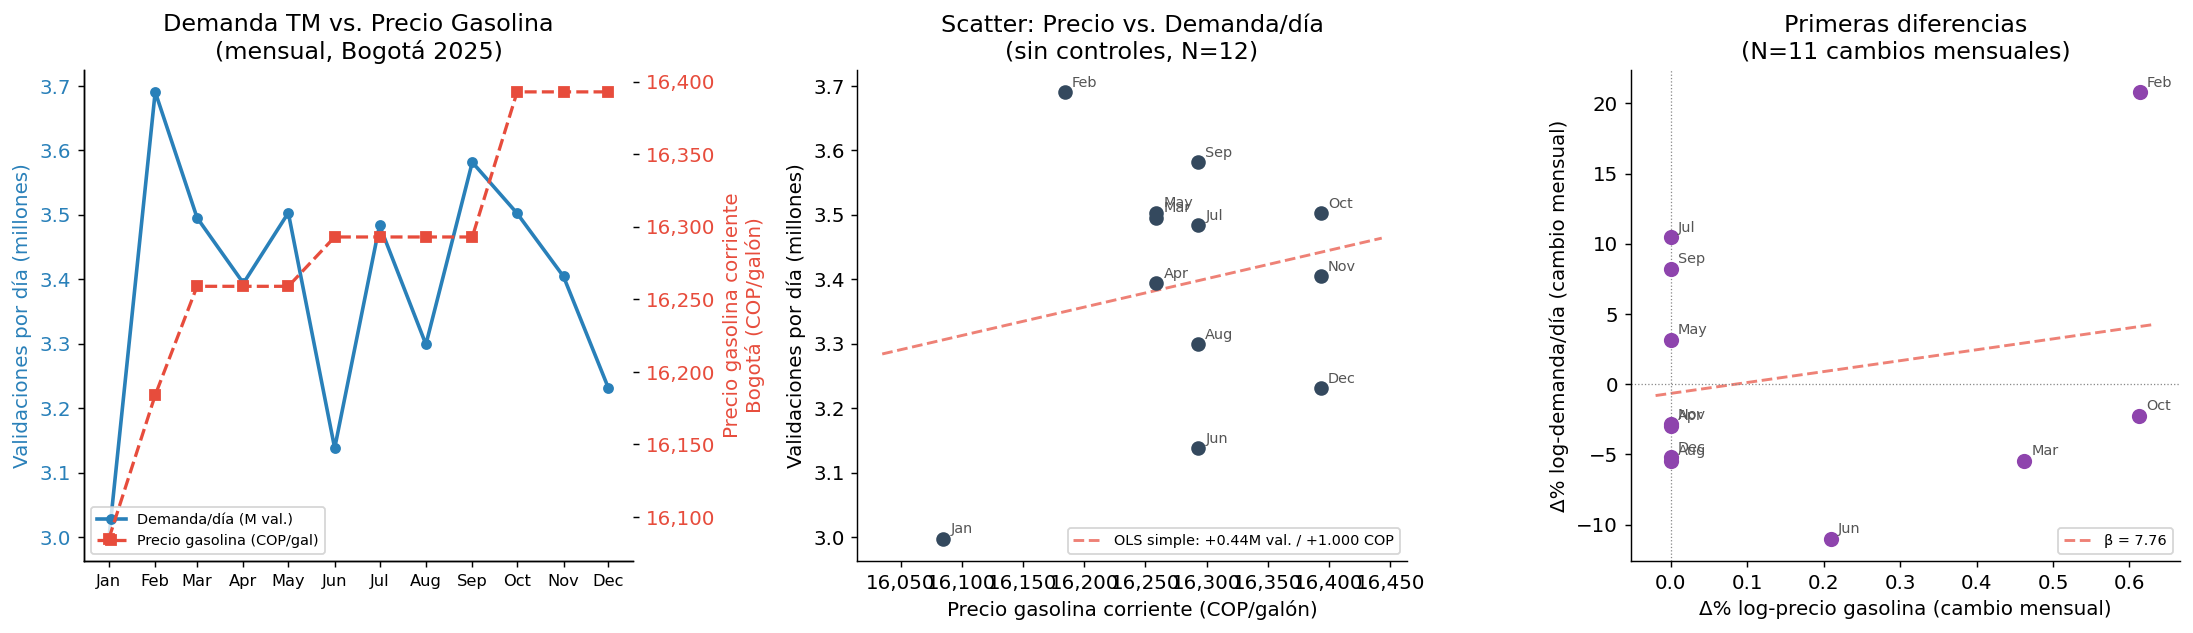

Figura guardada en reports/figures/combustible_precio_demanda.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

months_x = df.mes_dt
month_labels = [m.strftime('%b') for m in months_x]

# ── Panel 1: serie dual eje ──────────────────────────────────────────────────
ax1 = axes[0]
color_dem   = '#2980b9'
color_price = '#e74c3c'

ax1b = ax1.twinx()
ax1b.spines['top'].set_visible(False)

ax1.plot(months_x, df.val_dia / 1e6, 'o-', color=color_dem, lw=2, ms=5, label='Demanda/día (M val.)')
ax1b.plot(months_x, df.precio_cop_gal, 's--', color=color_price, lw=1.8, ms=5, label='Precio gasolina (COP/gal)')

ax1.set_xticks(months_x)
ax1.set_xticklabels(month_labels, fontsize=9)
ax1.set_ylabel('Validaciones por día (millones)', color=color_dem)
ax1b.set_ylabel('Precio gasolina corriente\nBogotá (COP/galón)', color=color_price)
ax1.tick_params(axis='y', labelcolor=color_dem)
ax1b.tick_params(axis='y', labelcolor=color_price)
ax1b.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1b.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='lower left')
ax1.set_title('Demanda TM vs. Precio Gasolina\n(mensual, Bogotá 2025)')

# ── Panel 2: scatter precio vs demanda/día ──────────────────────────────────
ax2 = axes[1]
ax2.scatter(df.precio_cop_gal, df.val_dia / 1e6, color='#34495e', s=50, zorder=3)

# Añadir etiquetas de mes
for _, row in df.iterrows():
    ax2.annotate(
        row['mes'].strftime('%b'),
        xy=(row.precio_cop_gal, row.val_dia / 1e6),
        xytext=(4, 3), textcoords='offset points',
        fontsize=8, color='#555'
    )

# Línea de regresión OLS simple (sin controles)
x_fit = df.precio_cop_gal.values
y_fit = df.val_dia.values / 1e6
coef  = np.polyfit(x_fit, y_fit, 1)
x_ln  = np.linspace(x_fit.min() - 50, x_fit.max() + 50, 100)
ax2.plot(x_ln, np.polyval(coef, x_ln), '--', color='#e74c3c', lw=1.6, alpha=0.7,
         label=f'OLS simple: {coef[0]*1000:+.2f}M val. / +1.000 COP')

ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax2.set_xlabel('Precio gasolina corriente (COP/galón)')
ax2.set_ylabel('Validaciones por día (millones)')
ax2.set_title('Scatter: Precio vs. Demanda/día\n(sin controles, N=12)')
ax2.legend(fontsize=8)

# ── Panel 3: primeras diferencias ──────────────────────────────────────────
ax3 = axes[2]
ax3.scatter(
    df_diff.d_log_precio * 100,
    df_diff.d_log_val_d * 100,
    color='#8e44ad', s=55, zorder=3
)
for _, row in df_diff.iterrows():
    ax3.annotate(
        row['mes'].strftime('%b'),
        xy=(row.d_log_precio * 100, row.d_log_val_d * 100),
        xytext=(4, 3), textcoords='offset points',
        fontsize=8, color='#555'
    )

# Línea de regresión en primeras diferencias
x_d   = df_diff.d_log_precio.values * 100
y_d   = df_diff.d_log_val_d.values * 100
coef_d = np.polyfit(x_d, y_d, 1)
x_dl  = np.linspace(x_d.min() - 0.02, x_d.max() + 0.02, 100)
ax3.plot(x_dl, np.polyval(coef_d, x_dl), '--', color='#e74c3c', lw=1.6, alpha=0.7,
         label=f'β = {coef_d[0]:.2f}')
ax3.axhline(0, color='#888', lw=0.7, ls=':')
ax3.axvline(0, color='#888', lw=0.7, ls=':')
ax3.set_xlabel('Δ% log-precio gasolina (cambio mensual)')
ax3.set_ylabel('Δ% log-demanda/día (cambio mensual)')
ax3.set_title('Primeras diferencias\n(N=11 cambios mensuales)')
ax3.legend(fontsize=8)

plt.tight_layout()
plt.savefig(PROJ / 'reports/figures/combustible_precio_demanda.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada en reports/figures/combustible_precio_demanda.png")

## 8. Resumen de resultados

In [10]:
b1  = mod1.params['log_precio']
p1  = mod1.pvalues['log_precio']
b2  = mod2.params['log_precio']
p2  = mod2.pvalues['log_precio']
b3  = mod3.params['d_log_precio']
p3  = mod3.pvalues['d_log_precio']

print("=" * 70)
print("RESUMEN — Efecto del precio de gasolina sobre demanda TM")
print("=" * 70)
print()
print("Especificación               Elasticidad     p-valor  Sig.")
print("-" * 70)

for label, b, p in [
    ("Spec 1a: log(val_mes)", b1, p1),
    ("Spec 1b: log(val_dia)", b2, p2),
    ("Spec 2:  Δlog(val_dia)", b3, p3),
]:
    sig = '***' if p<0.01 else ('**' if p<0.05 else ('*' if p<0.1 else 'ns'))
    print(f"  {label:<35} {b:+.4f}        {p:.3f}    {sig}")

print()
print("CONTEXTO DE LA VARIACIÓN:")
print(f"  Rango de precio 2025: {df.precio_cop_gal.min():,.0f} – {df.precio_cop_gal.max():,.0f} COP/gal")
print(f"  Variación total: +{df.precio_cop_gal.max()/df.precio_cop_gal.min()-1:.2%} en 12 meses")
print(f"  Niveles de precio distintos: {df.precio_cop_gal.nunique()} (de 12 meses)")
print(f"  Cambio máximo en un mes: {df.precio_cop_gal.diff().abs().max():,.0f} COP/gal")
print()
print("INTERPRETACIÓN:")
print(f"  La elasticidad estimada es {b2:+.3f} (Spec 1b) — no significativa.")
print(f"  Un +1% en precio corresponde a {b2:+.2f}% en demanda por día.")
print(f"  Con solo 12 obs y variación de precio <2%, el test carece de potencia")
print(f"  para detectar efectos del tamaño esperado (1–3% de elasticidad).")

RESUMEN — Efecto del precio de gasolina sobre demanda TM

Especificación               Elasticidad     p-valor  Sig.
----------------------------------------------------------------------
  Spec 1a: log(val_mes)               +10.4395        0.000    ***
  Spec 1b: log(val_dia)               +11.9274        0.117    ns
  Spec 2:  Δlog(val_dia)              +7.7644        0.693    ns

CONTEXTO DE LA VARIACIÓN:
  Rango de precio 2025: 16,085 – 16,393 COP/gal
  Variación total: +1.91% en 12 meses
  Niveles de precio distintos: 5 (de 12 meses)
  Cambio máximo en un mes: 100 COP/gal

INTERPRETACIÓN:
  La elasticidad estimada es +11.927 (Spec 1b) — no significativa.
  Un +1% en precio corresponde a +11.93% en demanda por día.
  Con solo 12 obs y variación de precio <2%, el test carece de potencia
  para detectar efectos del tamaño esperado (1–3% de elasticidad).


## 9. Interpretación causal

**Resultado:** Las especificaciones robustas (Spec 1b y Spec 2) no detectan un efecto estadísticamente significativo del precio de gasolina sobre la demanda de TransMilenio.

**Sobre el resultado de Spec 1a (β=+10.4, p=0.000):** Este coeficiente es espurio. El precio de gasolina sube monotónicamente durante 2025 — su correlación con la tendencia lineal es r=0.92 (VIF=6.2). La regresión con tendencia no puede desambiguar entre el efecto del precio y la tendencia secular de demanda cuando ambos evolucionan casi en paralelo con N=12. El coeficiente (+10.4) es económicamente implausible — implicaría que un aumento del 1% en el precio de la gasolina genera un 10% más de validaciones TM. Spec 1b (normalizada por días) y Spec 2 (primeras diferencias) no son significativas.

**Razones estructurales de la falta de señal:**

1. **Variación insuficiente.** El precio de gasolina corriente en Bogotá pasó de 16,085 a 16,393 COP/galón entre enero y diciembre 2025 — un incremento de +1.9% en todo el año. En 7 de los 11 cambios mensuales, el precio no varió en absoluto. Con tan poca señal en el regresor, el SE de la elasticidad es enorme.

2. **Potencia estadística.** N=12 observaciones mensuales. Para detectar una elasticidad de 0.1 (realista según la literatura) se necesitaría variación de precio de ≥10% o una serie histórica más larga.

3. **Mecanismo de largo plazo.** La sustitución modal ocurre principalmente en decisiones de compra de vehículo (largo plazo), no en el uso diario (corto plazo). La literatura estima elasticidades de corto plazo de transporte público respecto al precio de combustible de 0.05–0.15.

4. **Confusión con tendencia.** El precio tiene la misma forma monotónica que la tendencia anual de demanda (r=0.92). Son indistinguibles con N=12.

**Conclusión:** El análisis es **inconcluso por diseño**, no refutatorio. La hipótesis de sustitución modal es plausible pero el año 2025 no provee suficiente variación en precios para identificarla con datos mensuales.

**Para un análisis más robusto:**
- Serie histórica 2018–2025 (incluye ajustes mayores de ±10–20% en 2021–2023 por el desmonte acelerado del subsidio)
- Explotar variación transversal entre ciudades: las ciudades fronterizas (Cúcuta, Pasto) tienen precios regulados diferentes, lo que permite un diseño DiD ciudad × mes
